## Setup

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Create actor-critic model

Here we implement the equations of the actor-critic model put forward by Sam Gershman, August 12, 2021.

In [89]:
# TODO: move to its own python script and import here
class ActorCritic:
    """Implements an actor-critic model with sigmoidal policy a function of the difference between propensities """
    def __init__(self, beta, learning_rate, theta_a_init, theta_b_init, cumulative_reward_a, p_memory_b_given_a, p_memory_a, use_memory): # p_memory_a, p_memory_b
        self.beta = beta
        self.learning_rate = learning_rate
        self.theta_a = theta_a_init
        self.theta_b = theta_b_init
        self.cumulative_reward_a = cumulative_reward_a
        #self.average_reward_a = average_reward_a
        #self.average_reward_b = average_reward_b
        #self.p_memory_b = p_memory_b # vice versa
        self.p_memory_a = p_memory_a # overall probability of recognizing a, whether or not you recognize b
        self.p_memory_b_given_a = p_memory_b_given_a # TODO: we also test memory of b, i.e., p_mem_b. clarify why/when we use p_mem_b_given_a
        self.use_memory = use_memory
    
#     @property
#     def p_memory_ab(self):
#         # product rule of probability: p(a)p(b|a) = p(a,b)
#         # not sure this is necessary. it assumes we have access to p_mem_b_given_a and not p_mem_a_b
#         return p_memory_a*self.p_memory_b_given_a

    @staticmethod
    def sigmoid(x): 
        # define a general sigmoid function
        return 1./(1. + np.exp(-x))
    
    # eq.1
    def p_choose_a(self):
        # define the policy for choosing a, which is a sigmoid of the parameters of interest
        return self.sigmoid(self.beta*(self.theta_a - self.theta_b))

    # eq.3
    def partial_a(self):
        # define the partial derivative of p_choose_a with respect to theta_a
        # note: theta_b  = -1.*theta_a
        pi_a = self.p_choose_a()
        return self.beta*pi_a*(1. - pi_a)
    
    # eq. 3,4,7
    def gradient(self):
        # all the drama happens here: the gradient updates are opposite (stemming from the choice of p_choose_a)
        grad = np.array([self.partial_a(), -1.*self.partial_a()])
        # here we add the memory component for the chosen and unchosen items
        if self.use_memory:
            grad[0] = grad[0] * self.p_memory_a # TODO: is this necessary? 
            grad[1] = grad[1] * self.p_memory_b_given_a
        return grad
    
    # eq. 2
    def average_reward(self):
        # V = self.p_choose_a()*self.average_reward_a + (1. - self.p_choose_a())*self.average_reward_b
        # V = self.p_choose_a()*self.cumulative_reward_a
        V = self.cumulative_reward_a
        return V
    
    # eq. 2
    def theta_update(self, reward_a):
        grad = self.gradient()
        return self.learning_rate*(reward_a - self.average_reward())*grad
    # eq. 3+4
    def theta_step(self, reward_a):
        update = self.theta_update(reward_a)
        self.theta_a += update[0]
        self.theta_b += update[1]
    
        

## Testing the model

### general checkups 
We first make sure the sigmoid function works well.
Then, we want to make sure the model works. So we initialize thetas with the same value and want to see there is no preference for either a or b. 

In [90]:
actor_critic = ActorCritic(beta = 0.5, 
                           learning_rate = 0.1, 
                           theta_a_init = 1, 
                           theta_b_init = 1, 
                           cumulative_reward_a = 5., 
                           p_memory_b_given_a = 1,
                           p_memory_a = 1,
                           use_memory = 1)


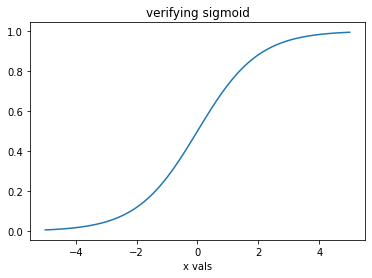

In [91]:
x = np.linspace(-5., 5., 100)
plt.plot(x, actor_critic.sigmoid(x))
plt.title('verifying sigmoid')
plt.xlabel('x vals');

In [92]:
assert(actor_critic.p_choose_a() == .5) # when we initialize with theta_a = theta_b = .5, there's no preference

### Assess how different reward values affect the propensities of a and b
Here we assume perfect memory of the choice set. We get a perfect inverse symmetry in propensities. That is, the larger the reward, the stronger is the propensity for the chosen item (a) and the weaker is for the unchosen item (b). 

In [93]:
#rewards = np.array([18., 7.5, 30., 0., 1.])
rewards = np.linspace(0, 1000, 100)
thetas = pd.DataFrame();
for i in range(len(rewards)):
    curr_actor_critic = ActorCritic(beta = 0.5, 
                                   learning_rate = 0.1, 
                                   theta_a_init = .5, 
                                   theta_b_init = .5, 
                                   cumulative_reward_a = 5., 
                                   p_memory_b_given_a = 1,
                                   p_memory_a = 1,
                                   use_memory = 1)
    curr_actor_critic.theta_step(reward_a = rewards[i])
    thetas.loc[i,"reward_a"] = rewards[i]
    thetas.loc[i,"theta_a"] = curr_actor_critic.theta_a
    thetas.loc[i,"theta_b"] = curr_actor_critic.theta_b    


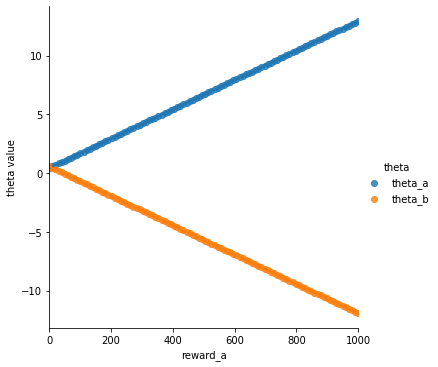

In [94]:
thetas_melt = pd.melt(thetas, 
                 id_vars='reward_a',
                 value_vars=['theta_a', 'theta_b'],
                 var_name='theta', 
                 value_name='theta value')
sns.lmplot(data=thetas_melt, x="reward_a", y="theta value", hue="theta", ci=None);

### Manipulate memory and reward 
Here we want to see what happens to the propensities when we change the memory and the reward together. In this version of the model the memory affects only the unchosen item. We indeed see a nice interaction between these parameters.
1. for unchosen items, memory increases the effect of reward on the inverse propensity. 
2. for chosen items, only reward affects the propensity in a linear fashion. 
3. note that the effect of reward is dependent on the average reward of items. so because the average reward is 5 for both the chosen and unchosen items, we do no see a positive value for the unchosen item and a negative value for the chosen item. when reward is zero, we see a slight preference towards the unchosen item. 



In [95]:
pair_memory = np.linspace(0, 1, 100) 
reward = np.array([0,50,100,150])
propensities_memory = np.empty((len(pair_memory), 4, len(reward)));

for j in range(len(reward)): 
    for i in range(len(pair_memory)):
        actor_critic_memory = ActorCritic(beta = 0.5, 
                           learning_rate = 0.1, 
                           theta_a_init = .5, 
                           theta_b_init = .5, 
                           cumulative_reward_a = 5., 
                           p_memory_b_given_a = pair_memory[i],
                           p_memory_a = 1,
                           use_memory = 1)
        actor_critic_memory.theta_step(reward_a = reward[j])
        # add to df
        propensities_memory[i,0,j] = pair_memory[i]
        propensities_memory[i,1,j] = reward[j]
        propensities_memory[i,2,j] = actor_critic_memory.theta_a
        propensities_memory[i,3,j] = actor_critic_memory.theta_b


In [96]:
propensities_memory_df = pd.DataFrame()
for j in range(len(reward)):    
    propensities_memory_df = propensities_memory_df.append(pd.DataFrame(propensities_memory[:,:,j], 
                                                                        columns=["pair_memory", "reward", "theta_a", "theta_b"]))
propensities_memory_df_melt = pd.melt(propensities_memory_df, 
                                     id_vars=['pair_memory','reward'],
                                     value_vars=['theta_a', 'theta_b'],
                                     var_name='theta', 
                                     value_name='theta value')
#propensities_memory_df_melt

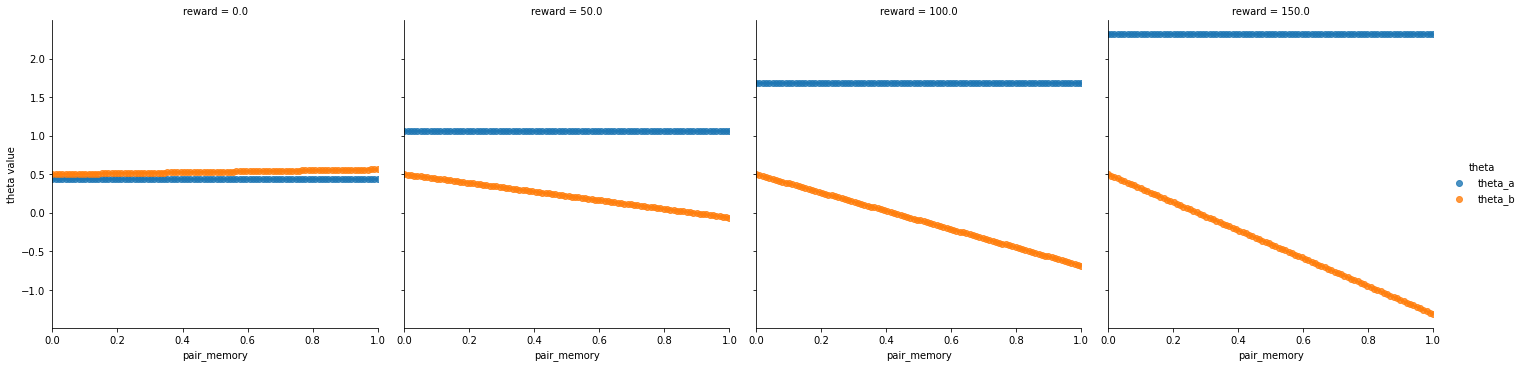

In [97]:
sns.lmplot(data=propensities_memory_df_melt, x="pair_memory", y="theta value", hue="theta", col="reward", ci=None);


In [98]:
reward = np.linspace(0, 1000, 100) 
pair_memory = np.array([0.,0.25,0.5,0.75,1.])
propensities_memory2 = np.empty((len(pair_memory), 4, len(reward)));

for j in range(len(reward)): 
    for i in range(len(pair_memory)):
        actor_critic_memory = ActorCritic(beta = 0.5, 
                           learning_rate = 0.1, 
                           theta_a_init = .5, 
                           theta_b_init = .5, 
                           cumulative_reward_a = 5., 
                           p_memory_b_given_a = pair_memory[i],
                           p_memory_a = 1,
                           use_memory = 1)
        actor_critic_memory.theta_step(reward_a = reward[j])
        # add to df
        propensities_memory2[i,0,j] = pair_memory[i]
        propensities_memory2[i,1,j] = reward[j]
        propensities_memory2[i,2,j] = actor_critic_memory.theta_a
        propensities_memory2[i,3,j] = actor_critic_memory.theta_b


In [99]:
propensities_memory_df2 = pd.DataFrame()
for j in range(len(reward)):    
    propensities_memory_df2 = propensities_memory_df2.append(pd.DataFrame(propensities_memory2[:,:,j], 
                                                                        columns=["pair_memory", "reward", "theta_a", "theta_b"]))
propensities_memory_df_melt2 = pd.melt(propensities_memory_df2, 
                                     id_vars=['pair_memory','reward'],
                                     value_vars=['theta_a', 'theta_b'],
                                     var_name='theta', 
                                     value_name='theta value')
# propensities_memory_df_melt

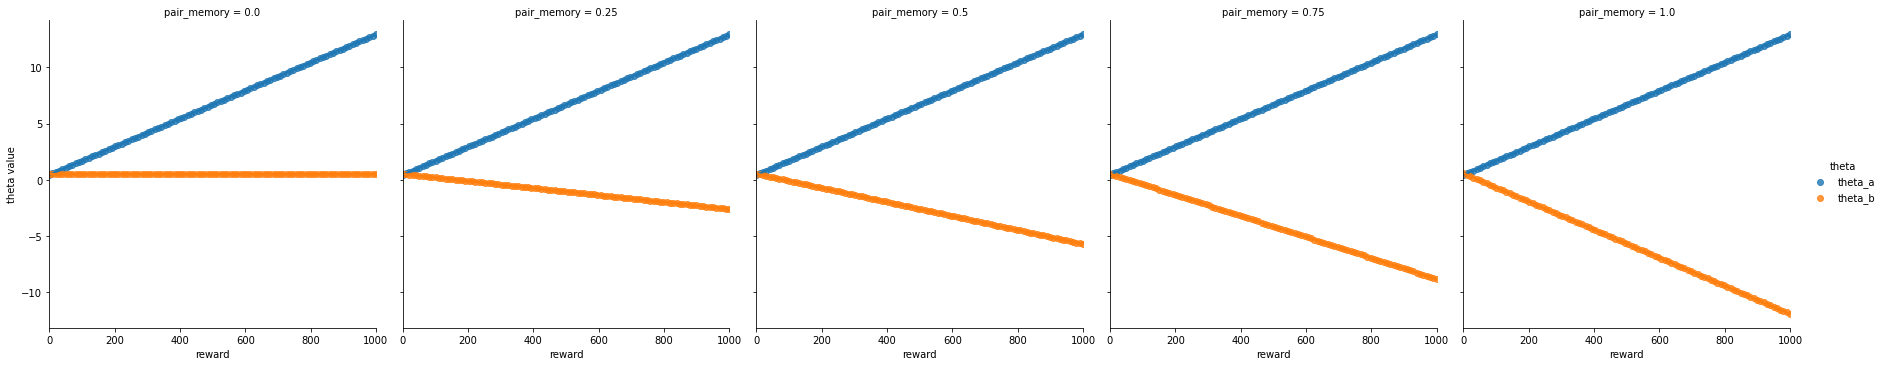

In [100]:
sns.lmplot(data=propensities_memory_df_melt2, col="pair_memory", y="theta value", hue="theta", x="reward", ci=None);


### Manipulate average reward 
Here we want to see what happens when we change the cumulative experienced reward. When the given reward is less than 1/2 the size of the average reward, we observe a flip in the propensities - chosen items become less favorable over unchosen ones. 

In [102]:
reward = np.linspace(0, 1000, 100) 
ave_reward = np.array([0,100,500,1000])
propensities_ave_reward = np.empty((len(reward), 4, len(ave_reward)));

for j in range(len(ave_reward)): 
    for i in range(len(reward)):
        actor_critic_ave_reward = ActorCritic(beta = 0.5, 
                               learning_rate = 0.1, 
                               theta_a_init = .5, 
                               theta_b_init = .5, 
                               cumulative_reward_a = ave_reward[j], 
                               p_memory_b_given_a = 1,
                               p_memory_a = 1,
                               use_memory = 1)
        actor_critic_ave_reward.theta_step(reward_a = reward[i])
        # add to df
        propensities_ave_reward[i,0,j] = ave_reward[j]
        propensities_ave_reward[i,1,j] = reward[i]
        propensities_ave_reward[i,2,j] = actor_critic_ave_reward.theta_a
        propensities_ave_reward[i,3,j] = actor_critic_ave_reward.theta_b


In [84]:
propensities_ave_reward_df = pd.DataFrame()
for j in range(len(ave_reward)):    
    propensities_ave_reward_df = propensities_ave_reward_df.append(pd.DataFrame(propensities_ave_reward[:,:,j], 
                                                                        columns=["average_reward", "reward", "theta_a", "theta_b"]))
propensities_ave_reward_df

,average_reward,reward,theta_a,theta_b,p_choose_a
0,0.0,0.00000,0.500000,0.500000,0.500000
1,0.0,10.10101,0.626263,0.373737,0.531524
2,0.0,20.20202,0.752525,0.247475,0.562798
3,0.0,30.30303,0.878788,0.121212,0.593581
4,0.0,40.40404,1.005051,-0.005051,0.623645
...,...,...,...,...,...
95,1000.0,959.59596,6.244949,-5.244949,0.996811
96,1000.0,969.69697,6.371212,-5.371212,0.997188
97,1000.0,979.79798,6.497475,-5.497475,0.997521
98,1000.0,989.89899,6.623737,-5.623737,0.997815


In [103]:
propensities_ave_reward_df = pd.DataFrame()
for j in range(len(ave_reward)):    
    propensities_ave_reward_df = propensities_ave_reward_df.append(pd.DataFrame(propensities_ave_reward[:,:,j], 
                                                                        columns=["average_reward", "reward", "theta_a", "theta_b"]))
propensities_ave_reward_df_melt = pd.melt(propensities_ave_reward_df, 
                                     id_vars=['average_reward','reward'],
                                     value_vars=['theta_a', 'theta_b'],
                                     var_name='theta', 
                                     value_name='theta value')

propensities_ave_reward_df_melt["r_minus_V"] = propensities_ave_reward_df_melt["reward"] - propensities_ave_reward_df_melt["average_reward"]

propensities_ave_reward_df_melt

,average_reward,reward,theta,theta value,r_minus_V
0,0.0,0.00000,theta_a,0.500000,0.00000
1,0.0,10.10101,theta_a,0.626263,10.10101
2,0.0,20.20202,theta_a,0.752525,20.20202
3,0.0,30.30303,theta_a,0.878788,30.30303
4,0.0,40.40404,theta_a,1.005051,40.40404
...,...,...,...,...,...
795,1000.0,959.59596,theta_b,1.005051,-40.40404
796,1000.0,969.69697,theta_b,0.878788,-30.30303
797,1000.0,979.79798,theta_b,0.752525,-20.20202
798,1000.0,989.89899,theta_b,0.626263,-10.10101


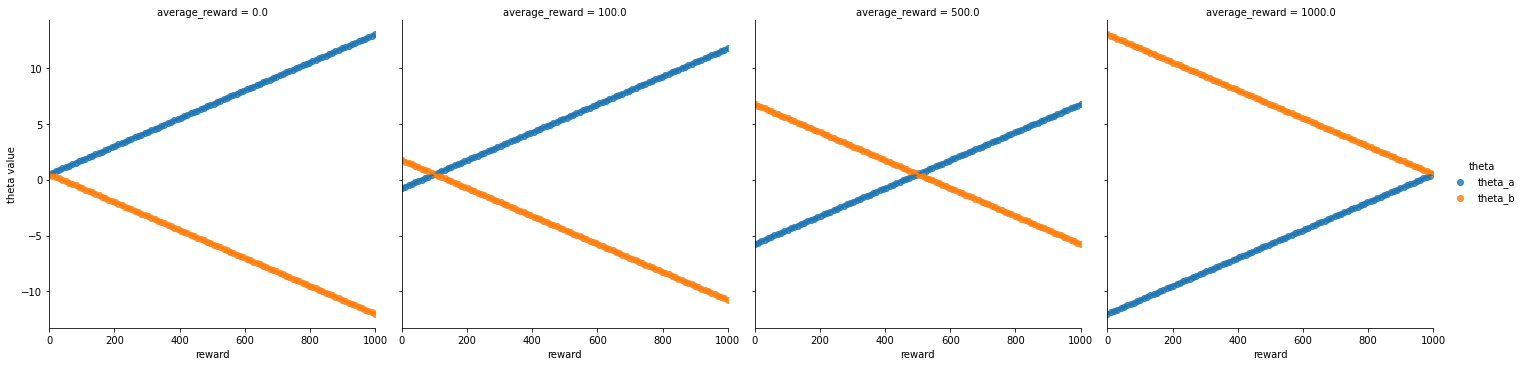

In [104]:
sns.lmplot(data=propensities_ave_reward_df_melt, x="reward", y="theta value", hue="theta", col="average_reward", ci=None);

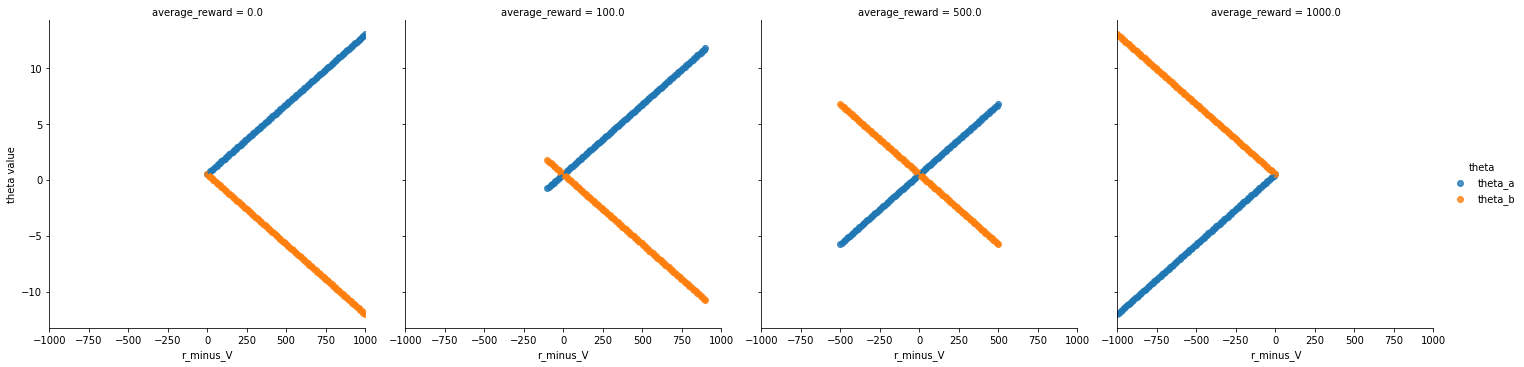

In [105]:
# plot
sns.lmplot(data=propensities_ave_reward_df_melt, x="r_minus_V", y="theta value", hue="theta", col="average_reward", ci=None)



**Here we want to see whether this property is dependent on magnitude of average reward or the ratio between reward and average reward**. It seems there is an interaction between the reward and the average reward given across trials. 
1. If the given reward is smaller than the average reward, then the propensity of the unchosen item is higher than that of the chosen item. 
2. The higher the average reward the larger is the difference between propensities - so the larger is the inverse choice bias. 

In [115]:
def plot_cumulative_ratio(rewards_ratio): 
    init_cumulative_reward_a = np.array([0,50,100])
    n_rewards = 100 # how many reward steps we are plotting
    propensities_ave_reward2 = np.empty((n_rewards, 4, len(init_cumulative_reward_a)));

    for i in range(len(init_cumulative_reward_a)):
        rewards = np.linspace(0, init_cumulative_reward_a[-1]*rewards_ratio, n_rewards) 
        for j in range(len(rewards)):
            actor_critic_ave_reward = ActorCritic(beta = 0.5, 
                                                  learning_rate = 0.1, 
                                                  theta_a_init = .5, 
                                                  theta_b_init = .5, 
                                                  cumulative_reward_a = init_cumulative_reward_a[i]*rewards_ratio, 
                                                  p_memory_b_given_a = 1,
                                                  p_memory_a = 1,
                                                  use_memory = 1)
            actor_critic_ave_reward.theta_step(reward_a = rewards[j])
            # add to df
            propensities_ave_reward2[j,0,i] = rewards[j]
            propensities_ave_reward2[j,1,i] = init_cumulative_reward_a[i]*rewards_ratio
            propensities_ave_reward2[j,2,i] = actor_critic_ave_reward.theta_a
            propensities_ave_reward2[j,3,i] = actor_critic_ave_reward.theta_b
            
    # melt the dfs for plotting
    propensities_ave_reward_df2 = pd.DataFrame()
    for i in range(len(init_cumulative_reward_a)):
        propensities_ave_reward_df2 = propensities_ave_reward_df2.append(pd.DataFrame(propensities_ave_reward2[:,:,i], 
                                                                                      columns=["reward", "cumulative_reward_a", "theta_a", "theta_b"]))

    propensities_ave_reward_df_melt2 = pd.melt(propensities_ave_reward_df2, 
                                         id_vars=['reward','cumulative_reward_a'],
                                         value_vars=['theta_a', 'theta_b'],
                                         var_name='theta', 
                                         value_name='theta_value')
    propensities_ave_reward_df_melt2["r_minus_V"] = propensities_ave_reward_df_melt2["reward"] - propensities_ave_reward_df_melt2["cumulative_reward_a"]
    
    # plot
    p = sns.lmplot(data=propensities_ave_reward_df_melt2, x="reward", y="theta_value", hue="theta", col="cumulative_reward_a", ci=None).set(xlim=(0, 300), ylim=(-5,5));
    
    return p;



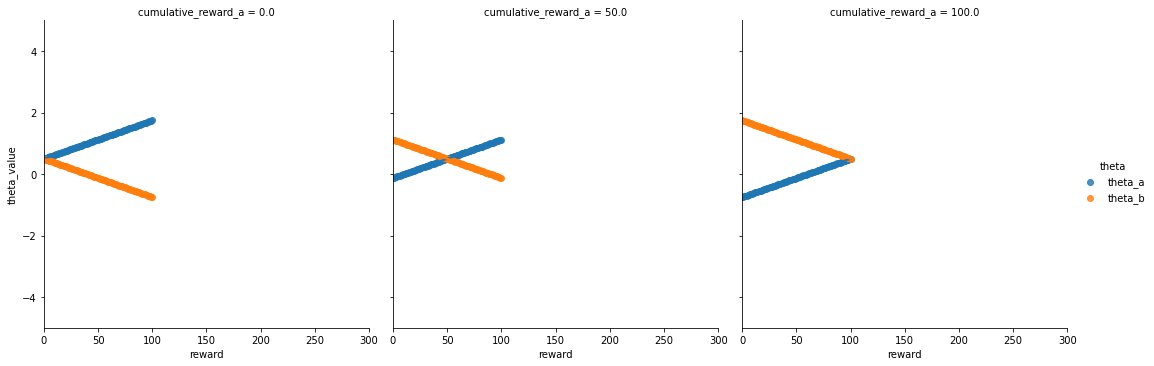

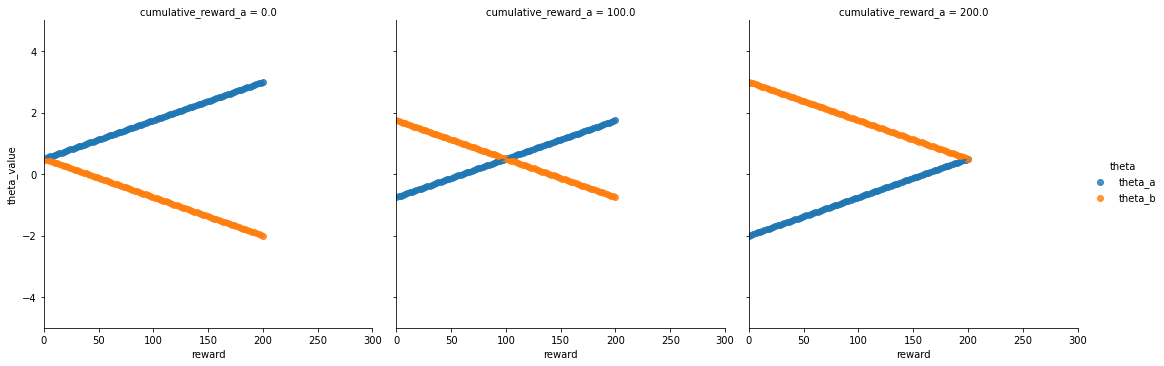

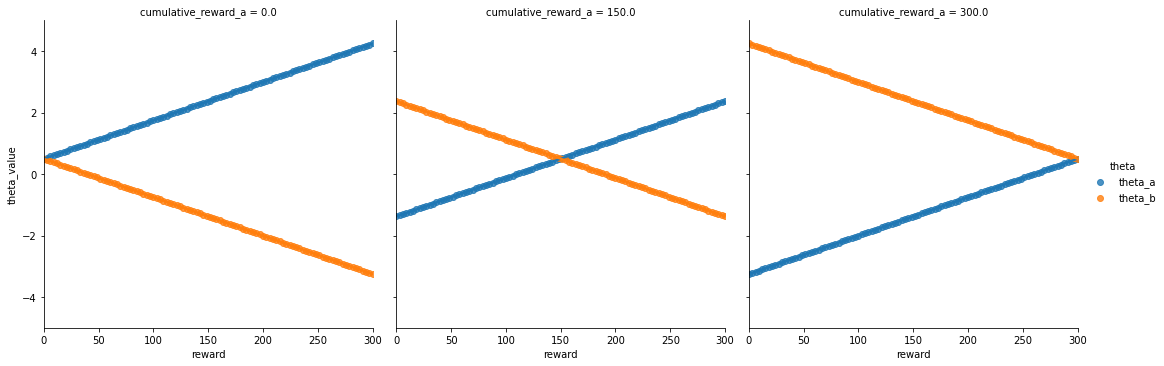

In [116]:
plot_cumulative_ratio(1)
plot_cumulative_ratio(2)
plot_cumulative_ratio(3)

## Reconstructing Actions from Memory
Not sure I follow this generative model. Usually we can just have $\theta$ and $V_i$ without the extra tilde.
We define a simple univariate Linear-Gaussian model for our measured values:
\begin{align}
V_i &\sim \mathcal{N}(\theta, \sigma^2_0) \quad \quad \text{(true latent value)} \\
\tilde{V}_i &= V_i + \epsilon \quad \quad \text{(measured value)} \\
\epsilon &\sim \mathcal{N}(0, 1) \quad \quad \text{(observation noise)}
\end{align}
The posterior is avaialable in closed form:
\begin{align}
p(V_i | \tilde{V_i})
\end{align}

## Questions for Sam
1. Which values should we include for V? (expected rewards) - the mean value of the **unchosen item** is not known for participants (and experimenter; it can be anything, this quantity doesn't exist anywhere in my experiments). Participants only observe the outcomes of the chosen items. I am not sure how to set this quantity.
2. Should the initial values for theta reflect the initial ratings we have for the paintings? 
3. Should we update the thetas of both a and b as a function of memory (i.e., Eq. 5 and 6), or only use Eq.7 to update the unchosen item and keeping the deterministic update for the chosen item?
4. How should we estimate the memory probabilities from data? Our memory phase includes two trials per item - one with the actual pairing from the deliberation phase (what we call a & b appearing together), and another trial with other items from the experiment (a & c for chosen, b & d for unchosen, where c, d are unchosen and chosen items, respectively, which appeared in other trials). should p(b|a) be the memory accuracy measure in the single trial where a & b appeared together? 

# notes to self

## Memory
\begin{align}
p(a,b) &= p(a) \cdot p(b|a) \\
&= p(b) \cdot p(a|b) \\
\end{align}

and in the case they're independent
\begin{align}
p(a,b) &= p(a) \cdot p(b) \iff a \perp b
\end{align}

What we _currently_ measure for each pair $a$ and $b$ is $p(a,b)$ (show the two items together and ask whether they remember the pair), $p(a)$, and $p(b)$, each with a different item. Thus, we have two memory trials per item.